In a classification setting, the goal is to use a learning algorithm ($\mathcal{A}$) which takes in the available data and gives us a classifier — an estimate of the decision boundary that separates classes. The classifier can then be used to predict the class label for unseen inputs.

Let the data given to us be of the form
$$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=0}^{N}$$

where $\mathbf{x}_i \in \mathbb{R}^d$ and $y_i \in \{0, 1\}$ (binary classification).

The predictive modeling task can be defined as,

$$\mathcal{A}(\mathcal{D}) \rightarrow \hat{f}(\mathbf{x})$$

where $\hat{f} : \mathbb{R}^d \rightarrow \{0, 1\}$.

## Bias-Variance Trade-off for Classification

Unlike regression where the bias-variance decomposition of MSE is clean and additive, classification with **0-1 loss** requires a different treatment. The decomposition due to **Domingos (2000)** defines the components as follows.

For a point $\mathbf{x}_0$, suppose we train the classifier on many bootstrap samples of the training data. Let:

- $y^* = f(\mathbf{x}_0)$ be the **true label** (the Bayes-optimal class).
- $y_m = \text{mode}\{\hat{f}_b(\mathbf{x}_0)\}$ be the **main prediction** — the most frequent prediction across bootstrap classifiers.

Then the decomposition of the expected 0-1 loss at $\mathbf{x}_0$ is:

$$E[\mathbb{1}(\hat{f}(\mathbf{x}_0) \neq y^*)] = \text{Bias}(\mathbf{x}_0) + \text{Net-Variance}(\mathbf{x}_0)$$

where:

- **Bias**: $\mathbb{1}(y_m \neq y^*)$ — equals 1 if the main prediction is wrong, 0 otherwise.
- **Variance**: $P(\hat{f}(\mathbf{x}_0) \neq y_m)$ — the probability that an individual bootstrap prediction disagrees with the main prediction.
- **Net-Variance**: Variance can *help* when bias is present (a "lucky" wrong main prediction might still get individual predictions right). So the net contribution of variance depends on the bias:
  - If **unbiased** ($y_m = y^*$): net-variance = variance (variance always hurts)
  - If **biased** ($y_m \neq y^*$): net-variance = $-$variance (variance can help by occasionally overriding the wrong main prediction)

This means that unlike regression, bias and variance are **not simply additive** under 0-1 loss — their interaction matters.

## Computational and Visual Example

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap

In [2]:
import ipywidgets as widgets
from ipywidgets import interact
from mlxtend.evaluate import bias_variance_decomp

In [3]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [4]:
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

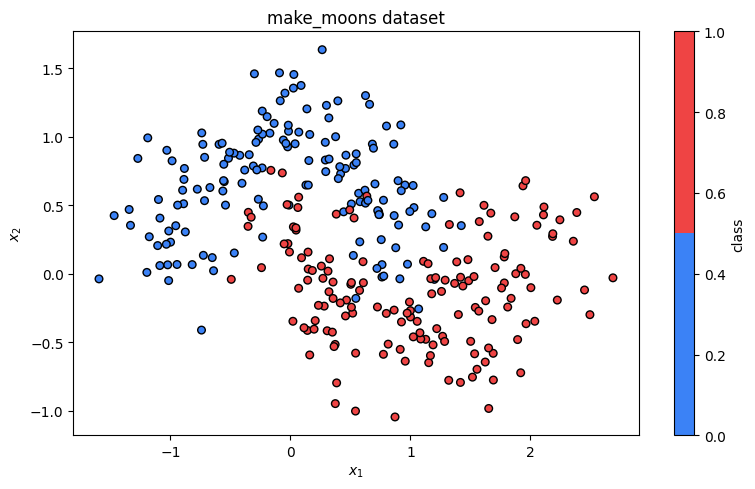

In [5]:
cmap_data = ListedColormap(['#3b82f6', '#ef4444'])
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_data, edgecolors='k', s=30)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('make_moons dataset')
plt.colorbar(label='class')
plt.tight_layout()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [7]:
models = {
    'DecisionTree': DecisionTreeClassifier,
    # 'RandomForest': RandomForestClassifier,
    'kNN': KNeighborsClassifier,
    'SVM': SVC
}

In [8]:
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
grid_step = 0.05
xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, grid_step),
    np.arange(x2_min, x2_max, grid_step)
)
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

In [9]:
def get_predictions(clf, reps=100):
    """Bootstrap resample and predict on the meshgrid `reps` times."""
    predictions = []
    for _ in range(reps):
        idx = np.random.choice(len(X), size=len(X), replace=True)
        X_boot, y_boot = X[idx], y[idx]
        clf.fit(X_boot, y_boot)
        preds = clf.predict(grid_points)
        predictions.append(preds)
    return np.array(predictions)

In [10]:
def bayes_label_at(point):
    """Approximate true label using majority vote from a noiseless make_moons.
    We generate a large noiseless dataset and return the label of the nearest point."""
    X_clean, y_clean = make_moons(n_samples=10000, noise=0.0, random_state=0)
    dists = np.sum((X_clean - point) ** 2, axis=1)
    return y_clean[np.argmin(dists)]

In [11]:
def visualize(predictions, bias_total, var_total, clf):
    """Interactive visualization of bias-variance decomposition for classification."""
    print(clf)
    print("--------------------------------------------")

    cmap_boundary = ListedColormap(['#93c5fd', '#fca5a5'])
    cmap_data = ListedColormap(['#3b82f6', '#ef4444'])

    @interact(
        x1_0=(float(x1_min + 0.1), float(x1_max - 0.1), 0.1),
        x2_0=(float(x2_min + 0.1), float(x2_max - 0.1), 0.1),
    )
    def plot_graphs(x1_0=0.5, x2_0=0.25):
        x_0 = np.array([x1_0, x2_0])

        # Find nearest grid point index
        dists = np.sum((grid_points - x_0) ** 2, axis=1)
        x_0_idx = np.argmin(dists)
        x_0_snap = grid_points[x_0_idx]

        preds_at_x0 = predictions[:, x_0_idx]
        main_pred = int(np.round(np.mean(preds_at_x0 >= 0.5)))  # mode
        frac_class1 = np.mean(preds_at_x0 == 1)
        frac_class0 = np.mean(preds_at_x0 == 0)

        true_label = bayes_label_at(x_0_snap)
        bias = int(main_pred != true_label)
        variance = np.mean(preds_at_x0 != main_pred)
        if bias == 0:
            net_variance = variance
        else:
            net_variance = -variance
        error = np.mean(preds_at_x0 != true_label)

        # --- Average decision boundary (probability of class 1 at each grid point) ---
        prob_class1 = np.mean(predictions, axis=0)

        fig = plt.figure(figsize=(18, 16), constrained_layout=True)
        gs = GridSpec(3, 2, figure=fig)

        # --- Top-left: decision boundary heatmap + data ---
        ax1 = fig.add_subplot(gs[0, 0])
        Z = prob_class1.reshape(xx1.shape)
        ax1.contourf(xx1, xx2, Z, levels=np.linspace(0, 1, 11), cmap='RdBu_r', alpha=0.7)
        ax1.contour(xx1, xx2, Z, levels=[0.5], colors='k', linewidths=2)
        ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_data, edgecolors='k', s=15, alpha=0.6)
        ax1.scatter(*x_0_snap, marker='x', s=200, c='lime', linewidths=3, zorder=5)
        ax1.set_xlabel('$x_1$')
        ax1.set_ylabel('$x_2$')
        ax1.set_title('Average decision boundary (P(class=1) heatmap)', fontsize=13)

        # --- Top-right: class proportion bar chart at x_0 ---
        ax2 = fig.add_subplot(gs[0, 1])
        bars = ax2.bar(['Class 0', 'Class 1'], [frac_class0, frac_class1],
                       color=['#3b82f6', '#ef4444'], edgecolor='k')
        ax2.set_ylim(0, 1)
        ax2.set_ylabel('Proportion')
        true_label_str = f'Class {true_label}'
        main_pred_str = f'Class {main_pred}'
        ax2.set_title(
            f'Predictions at $\\mathbf{{x}}_0$ '
            f'(true={true_label_str}, main={main_pred_str})',
            fontsize=13,
        )
        for bar, val in zip(bars, [frac_class0, frac_class1]):
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=12)

        # --- Middle: error decomposition at x_0 ---
        ax3 = fig.add_subplot(gs[1, :])
        bias_color = '#ef4444'
        var_color = '#f97316'
        err_color = '#6b7280'
        bar_height = 0.3

        if bias == 0:
            ax3.barh('Error', bias, color=bias_color, height=bar_height, label=f'Bias = {bias}')
            ax3.barh('Error', variance, left=bias, color=var_color, height=bar_height,
                     label=f'Variance = {variance:.3f}')
        else:
            ax3.barh('Error', error, color=err_color, height=bar_height,
                     label=f'Error = {error:.3f}')
            ax3.barh('Components', bias, color=bias_color, height=bar_height,
                     label=f'Bias = {bias}')
            ax3.barh('Components', variance, left=0, color=var_color, height=bar_height,
                     alpha=0.5, label=f'Variance = {variance:.3f} (helps)')

        ax3.set_xlim(0, 1.1)
        ax3.legend(loc='upper right', fontsize=12)
        ax3.set_title(
            f'Error decomposition at $\\mathbf{{x}}_0$  '
            f'(Error={error:.3f} = Bias({bias}) + NetVar({net_variance:+.3f}))',
            fontsize=13,
        )

        # --- Bottom: overall error decomposition on test data ---
        ax4 = fig.add_subplot(gs[2, :])
        ax4.barh('Error', bias_total, color=bias_color, height=bar_height, label=f'Avg Bias = {bias_total:.4f}')
        ax4.barh('Error', var_total, left=bias_total, color=var_color, height=bar_height,
                 label=f'Avg Variance = {var_total:.4f}')
        ax4.set_xlim(0, max(0.5, bias_total + var_total + 0.05))
        ax4.legend(loc='upper right', fontsize=12)
        ax4.set_title('Bias-Variance decomposition on test data (0-1 loss)', fontsize=13)

In [12]:
@interact
def select_classifier(model=list(models.keys())):
    print("--------------------------------------------")
    if model == 'DecisionTree':
        @interact
        def select_params(max_depth=[2, 3, 4, 5, 50], max_features=["sqrt", "log2", None]):
            clf = DecisionTreeClassifier(max_depth=max_depth, max_features=max_features, random_state=42)
            predictions = get_predictions(clf)
            _, bias_total, var_total = bias_variance_decomp(
                clf, X_train, y_train, X_test, y_test,
                loss='0-1_loss', num_rounds=100, random_seed=42,
            )
            visualize(predictions, bias_total, var_total, clf)

    # elif model == 'RandomForest':
    #     @interact
    #     def select_params(n_estimators=[10, 50, 100, 200, 300, 500], max_depth=[2,3, 5,10,15]):
    #         clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
    #         predictions = get_predictions(clf)
    #         _, bias_total, var_total = bias_variance_decomp(clf, X_train, y_train, X_test, y_test, loss='mse',
    #                                                     num_rounds=100, random_seed=42)
    #         test(predictions, bias_total, var_total, clf)
    
    elif model == 'SVM':
        @interact
        def select_params(
            kernel=['rbf', 'poly', 'linear'],
            degree=[2, 3, 4],
            gamma=['scale', 'auto'],
            C=[0.1, 1, 10, 100],
        ):
            clf = SVC(kernel=kernel, degree=degree, gamma=gamma, C=C)
            predictions = get_predictions(clf)
            _, bias_total, var_total = bias_variance_decomp(
                clf, X_train, y_train, X_test, y_test,
                loss='0-1_loss', num_rounds=100, random_seed=42,
            )
            visualize(predictions, bias_total, var_total, clf)

    elif model == 'kNN':
        @interact
        def select_params(
            n_neighbors=[1, 3, 5, 10, 25, 75, 100, X_train.shape[0]],
            weights=['uniform', 'distance'],
            metric=['euclidean', 'manhattan'],
        ):
            clf = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)
            predictions = get_predictions(clf)
            _, bias_total, var_total = bias_variance_decomp(
                clf, X_train, y_train, X_test, y_test,
                loss='0-1_loss', num_rounds=100, random_seed=42,
            )
            visualize(predictions, bias_total, var_total, clf)

interactive(children=(Dropdown(description='model', options=('DecisionTree', 'kNN', 'SVM'), value='DecisionTre…